<center>
  <h1 style="font-size:35px; font-family: 'Times New Roman'; letter-spacing: 0.1em;">
    Smart Greenhouse - DecisionTreeClassifier
  </h1>
</center>
<center>
  <img src=https://myhouse.htgetrid.com/images/article/orig/2018/06/umnaya-teplica-osobennosti-konstrukcii-i-etapy-avtomatizacii-1.jpg
       alt="Smart Greenhouse" 
       style="width:58%; border-radius:15px; box-shadow: 0 0 10px #333;">
</center>


## About the Dataset

- **Plant_Type** – Type of plant being monitored *(Cucumber or Quinoa)*.

- **Temperature** – Ambient temperature inside the greenhouse (°C).

- **Soil_Moisture** – Soil moisture level as a percentage (%), indicating water content in the soil.

- **LDR** – Light intensity measured using Light Dependent Resistor (LDR), representing brightness level.

- **PWM** – Pulse Width Modulation value used to control devices (e.g., fan speed or light intensity).

- **Heater** – Indicates whether the heating system is turned **on** or **off** based on temperature.

- **Pump** – Indicates whether the water pump is **on** or **off** depending on soil moisture.

- **Light** – Indicates whether artificial lighting is **on** or **off** based on light intensity.

- **Fan** – Indicates whether the ventilation fan is **on** or **off** based on temperature.

<h1 style="font-family: 'Times New Roman'; letter-spacing: 0.08em;">Importing the Essential Libraries</h1>

In [ ]:
import pandas as pd
import numpy as np
import streamlit as st
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix
from sklearn.model_selection import train_test_split



<h1 style="font-family: 'Times New Roman'; letter-spacing: 0.08em;">Load the Data</h1>

In [226]:
data=pd.read_csv(r"C:\Users\Teto\Desktop\a.csv")

<h1 style="font-family: 'Times New Roman'; letter-spacing: 0.08em;">Data Preorocessing</h1>

In [227]:
data

,Plant_Type,Temperature,Soil_Moisture,LDR,PWM,Heater,Pump,Light,Fan
0,Quinoa,31.000000,77.000000,419.000000,180.000000,off,off,off,on
1,Cucumber,30.000000,77.000000,293.000000,220.000000,off,off,on,on
2,Quinoa,25.000000,64.000000,211.000000,180.000000,on,off,on,off
3,Cucumber,32.000000,53.000000,403.000000,120.000000,off,on,off,on
4,Cucumber,23.000000,47.000000,561.000000,180.000000,on,on,off,off
...,...,...,...,...,...,...,...,...,...
75,Quinoa,20.988256,55.995782,493.007188,219.991337,on,on,off,off
76,Cucumber,35.019373,39.991680,247.006971,180.014113,off,on,on,on
77,Quinoa,34.011641,68.990811,281.011978,219.998501,off,off,on,on
78,Quinoa,26.000858,66.992564,314.987665,120.002715,off,off,on,off


In [228]:
data.shape

(80, 9)

In [229]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Plant_Type     80 non-null     object 
 1   Temperature    80 non-null     float64
 2   Soil_Moisture  80 non-null     float64
 3   LDR            80 non-null     float64
 4   PWM            80 non-null     float64
 5   Heater         80 non-null     object 
 6   Pump           80 non-null     object 
 7   Light          80 non-null     object 
 8   Fan            80 non-null     object 
dtypes: float64(4), object(5)
memory usage: 5.8+ KB


In [230]:
data.describe()

,Temperature,Soil_Moisture,LDR,PWM
count,80.000000,80.000000,80.000000,80.000000
mean,27.224790,59.724440,404.450720,181.000311
std,4.401029,12.265980,124.363044,35.421023
min,19.996129,39.991680,199.995016,119.997531
25%,23.000000,49.745549,290.002995,179.992027
50%,27.495476,57.491836,401.999052,180.000000
75%,31.000000,69.747977,527.750000,219.995437
max,35.019373,80.000000,587.000000,220.015274


In [231]:
data.columns

Index(['Plant_Type', 'Temperature', 'Soil_Moisture', 'LDR', 'PWM', 'Heater',
       'Pump', 'Light', 'Fan'],
      dtype='object')

In [232]:
data.duplicated().sum()

0

In [233]:
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
Plant_Type       0
Temperature      0
Soil_Moisture    0
LDR              0
PWM              0
Heater           0
Pump             0
Light            0
Fan              0
dtype: int64


In [234]:
X = data.drop(["Plant_Type"], axis=1)

Y = data[["Plant_Type"]]


In [235]:
binary_cols = ['Heater', 'Pump', 'Light', 'Fan']

X[binary_cols] = X[binary_cols].replace({
    'on': 1, 'off': 0,
    'ON': 1, 'OFF': 0
})
X[binary_cols] = X[binary_cols].astype(int)

C:\Users\Teto\AppData\Local\Temp\ipykernel_22816\3946485211.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[binary_cols] = X[binary_cols].replace({


In [236]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer



binary_cols = ['Heater', 'Pump', 'Light', 'Fan']
data[binary_cols] = data[binary_cols].replace({'on': 1, 'off': 0})


data = pd.get_dummies(data, columns=['Plant_Type'], drop_first=False)

data = data.astype(int)

C:\Users\Teto\AppData\Local\Temp\ipykernel_22816\2768967082.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[binary_cols] = data[binary_cols].replace({'on': 1, 'off': 0})


In [237]:
data

,Temperature,Soil_Moisture,LDR,PWM,Heater,Pump,Light,Fan,Plant_Type_Cucumber,Plant_Type_Quinoa
0,31,77,419,180,0,0,0,1,0,1
1,30,77,293,220,0,0,1,1,1,0
2,25,64,211,180,1,0,1,0,0,1
3,32,53,403,120,0,1,0,1,1,0
4,23,47,561,180,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
75,20,55,493,219,1,1,0,0,0,1
76,35,39,247,180,0,1,1,1,1,0
77,34,68,281,219,0,0,1,1,0,1
78,26,66,314,120,0,0,1,0,0,1


In [238]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.8632137 ,  1.41729849,  0.1177285 , -0.02841877, -0.81649658,
        -1.1055416 , -0.90453403,  1.29099445],
       [ 0.63456056,  1.41729849, -0.90182648,  1.10797892, -0.81649658,
        -1.1055416 ,  1.1055416 ,  1.29099445],
       [-0.50870516,  0.35076981, -1.56534638, -0.02841877,  1.22474487,
        -1.1055416 ,  1.1055416 , -0.77459667],
       [ 1.09186684, -0.55167753, -0.0117388 , -1.7330153 , -0.81649658,
         0.90453403, -0.90453403,  1.29099445],
       [-0.96601144, -1.04392154,  1.26675077, -0.02841877,  1.22474487,
         0.90453403, -0.90453403, -0.77459667],
       [ 1.77782627, -0.96188087, -0.15738951,  1.10797892, -0.81649658,
         0.90453403,  1.1055416 ,  1.29099445],
       [-0.05139887, -0.14147419,  1.177742  , -0.02841877, -0.81649658,
         0.90453403, -0.90453403, -0.77459667],
       [-1.42331773, -0.30555553,  0.03681144,  1.10797892,  1.22474487,
         0.90453403, -0.90453403, -0.77459667],
       [-0.96601144,  0.02260714

In [239]:
data["Plant_Type_Cucumber"].value_counts()


Plant_Type_Cucumber
1    46
0    34
Name: count, dtype: int64

In [240]:
data["Plant_Type_Quinoa"].value_counts()


Plant_Type_Quinoa
0    46
1    34
Name: count, dtype: int64

<h1 style="font-family: 'Times New Roman'; letter-spacing: 0.08em;">Visualization</h1>

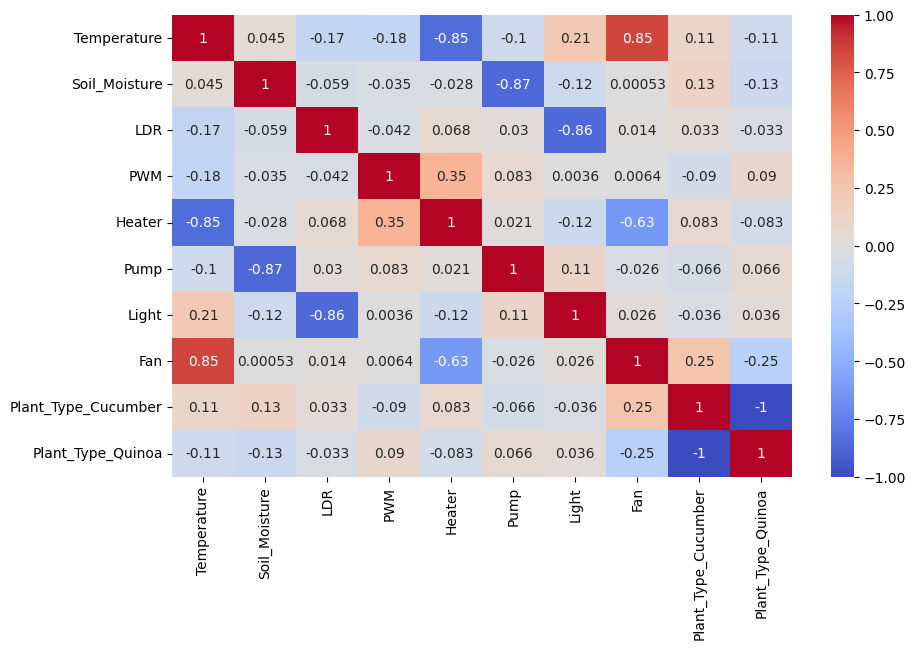

In [241]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()


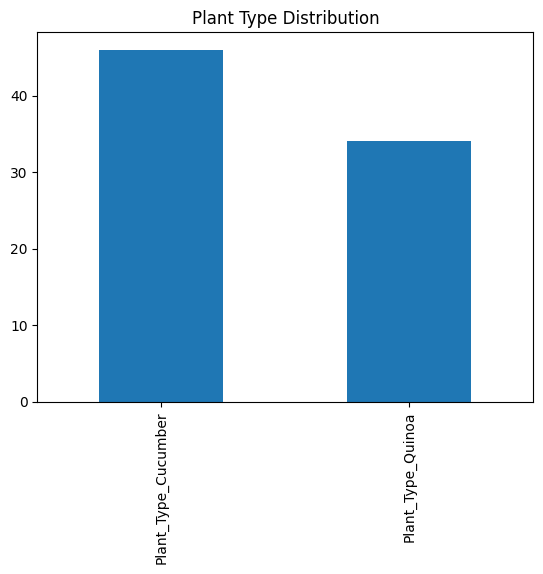

In [242]:
plant_cols = [col for col in data.columns if "Plant_Type" in col]

data[plant_cols].sum().plot(kind='bar')
plt.title("Plant Type Distribution")
plt.show()

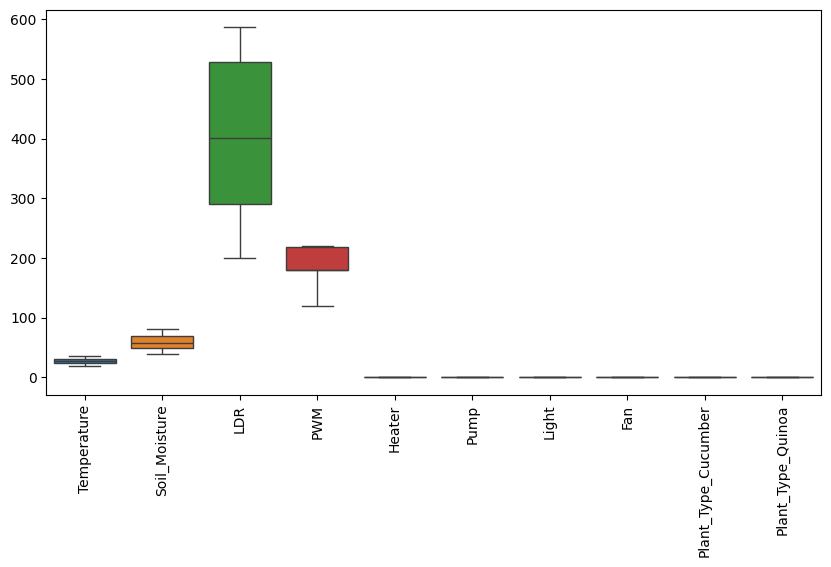

In [243]:
plt.figure(figsize=(10,5))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

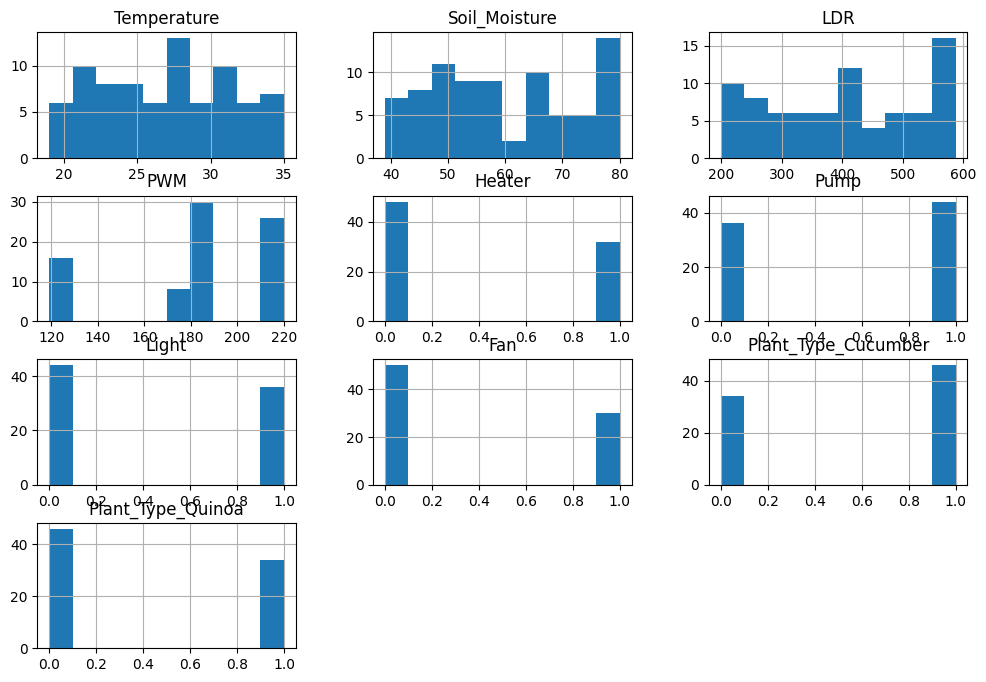

In [244]:
data.hist(figsize=(12,8))
plt.show()

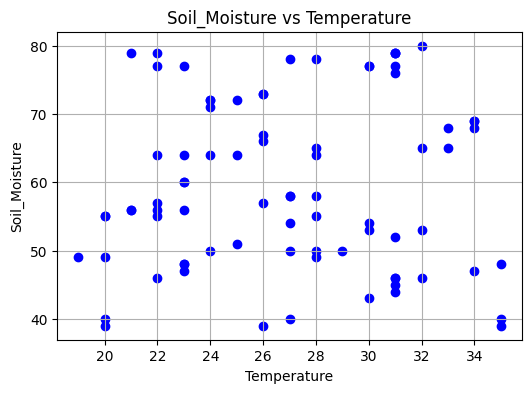

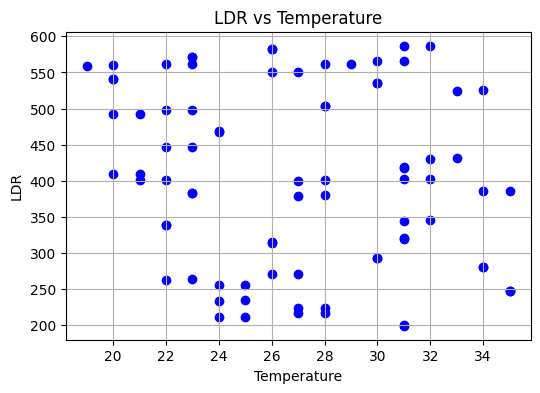

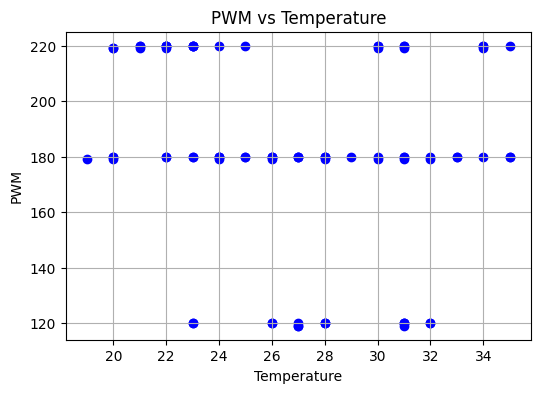

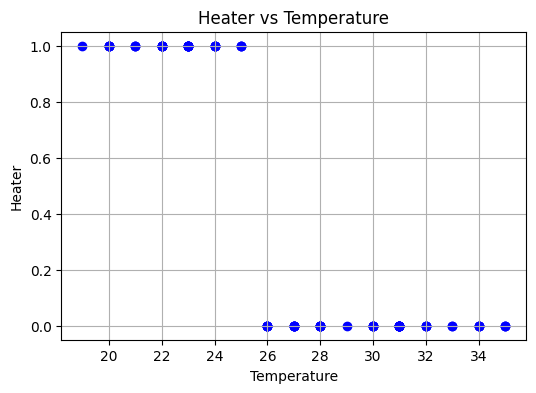

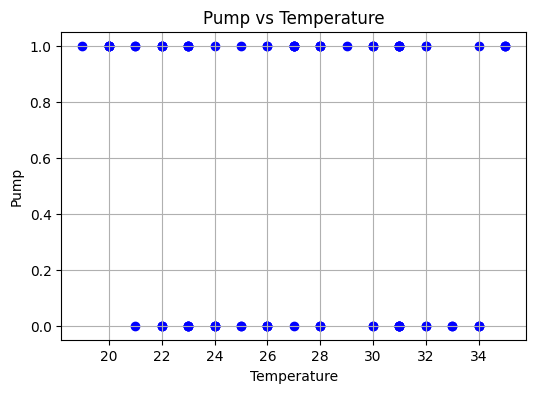

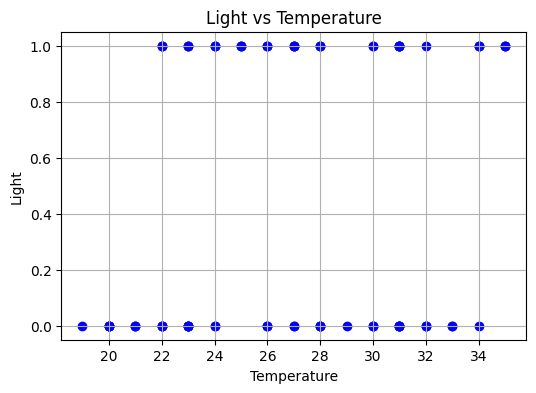

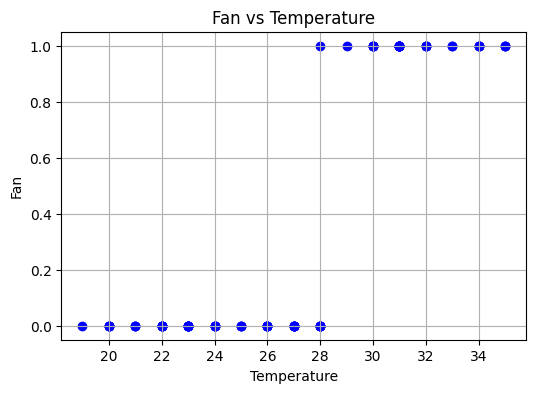

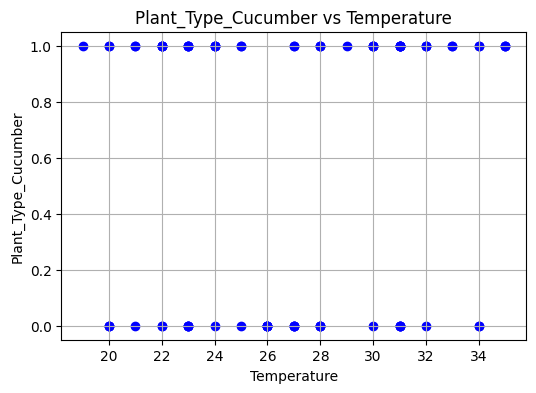

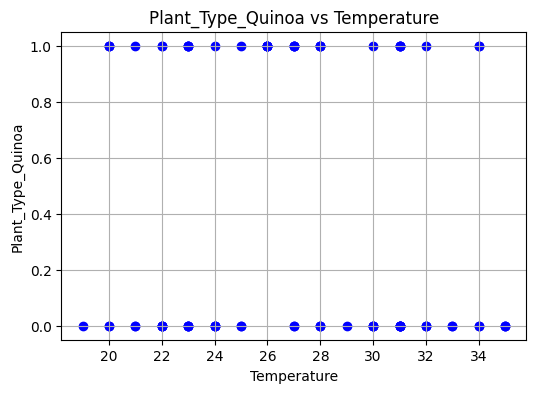

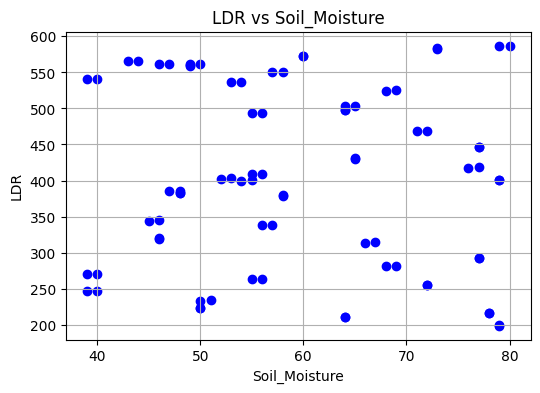

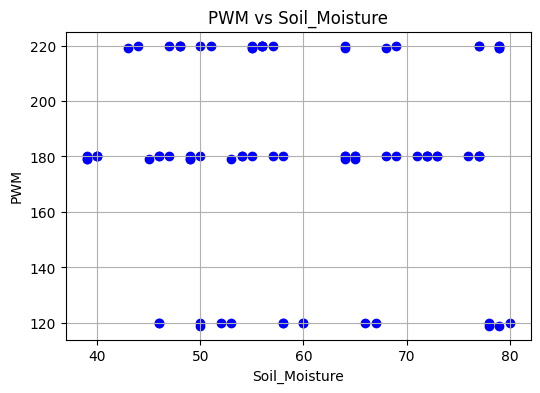

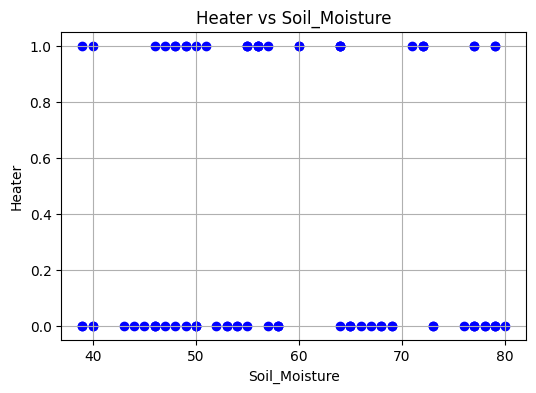

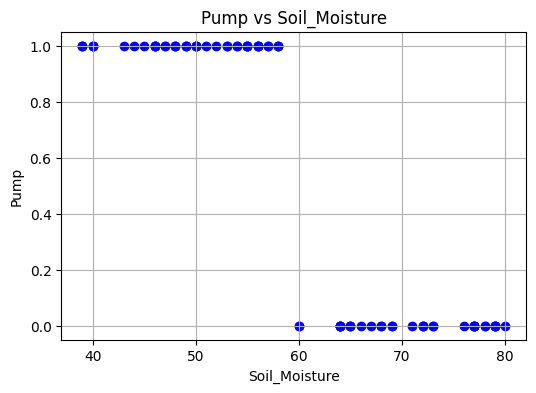

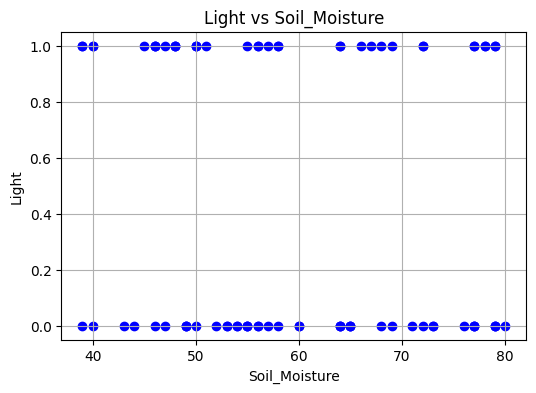

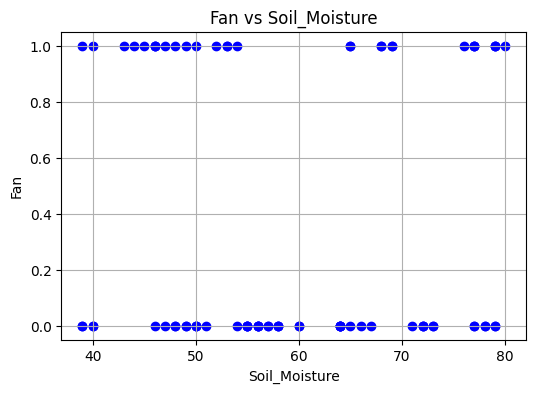

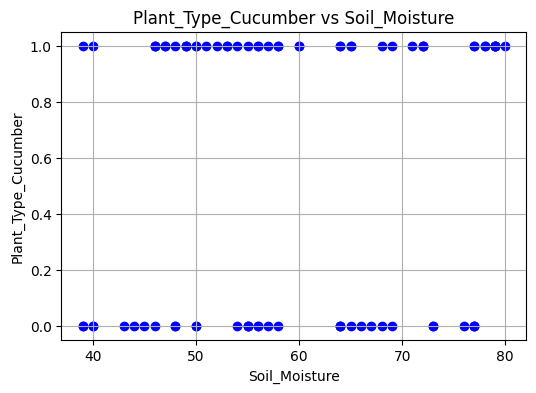

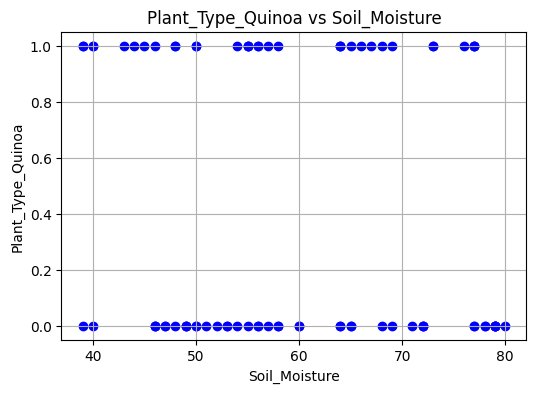

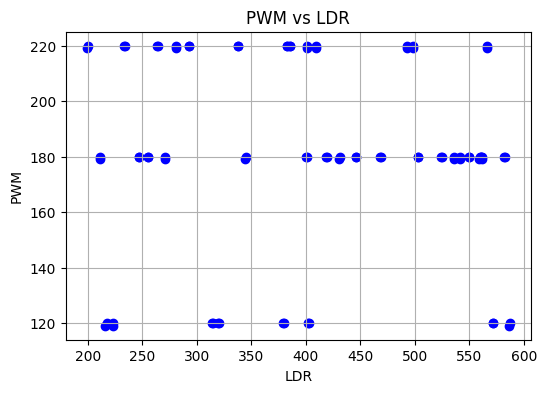

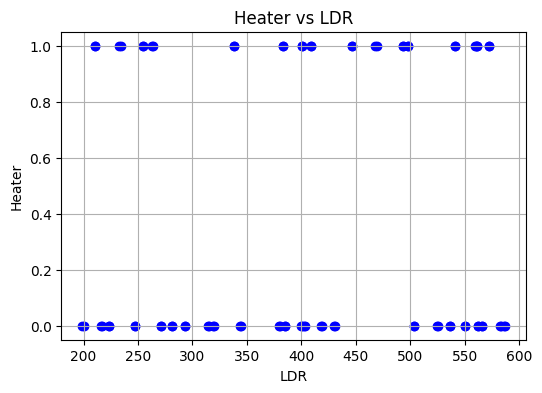

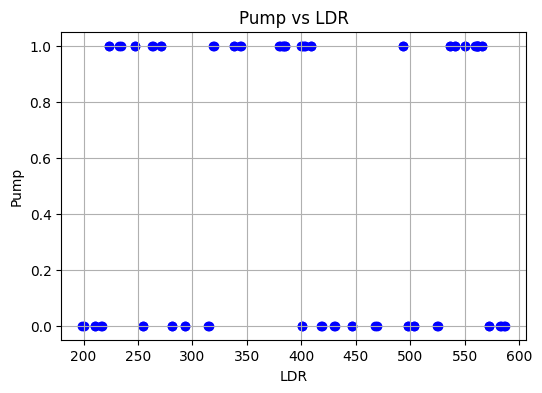

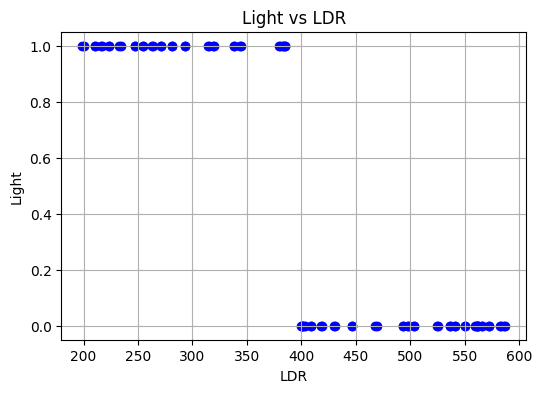

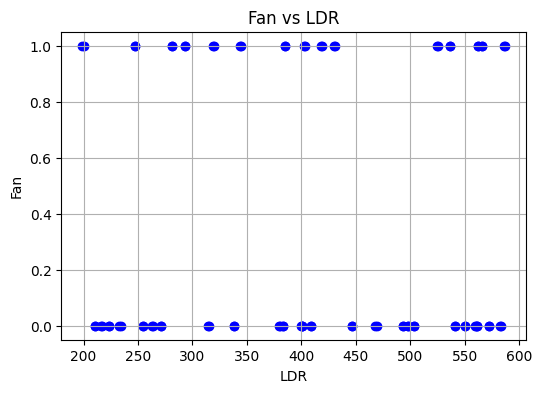

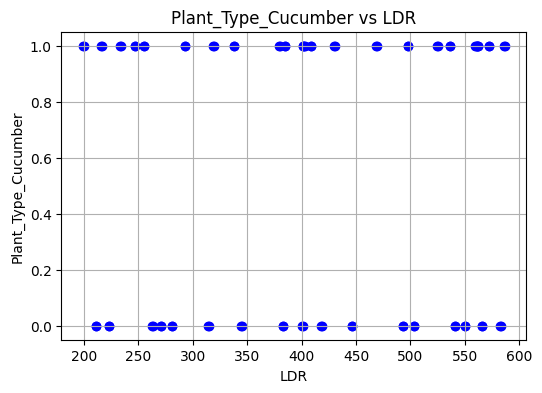

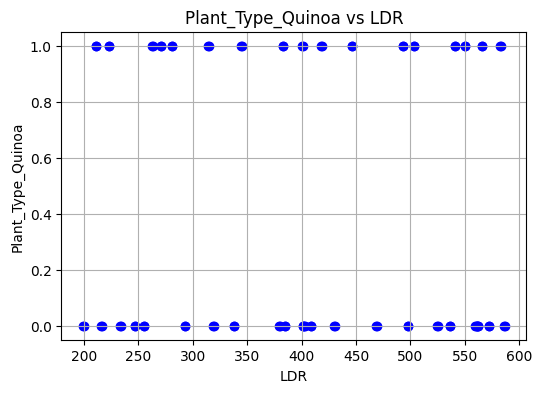

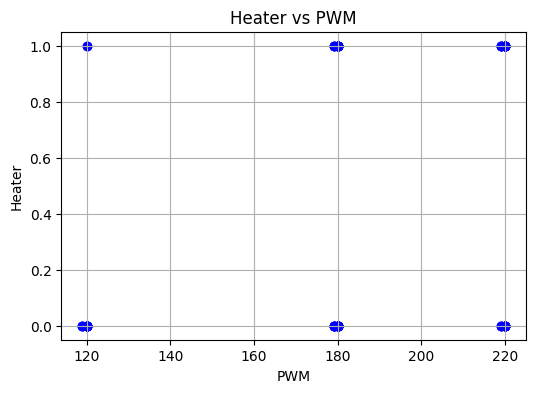

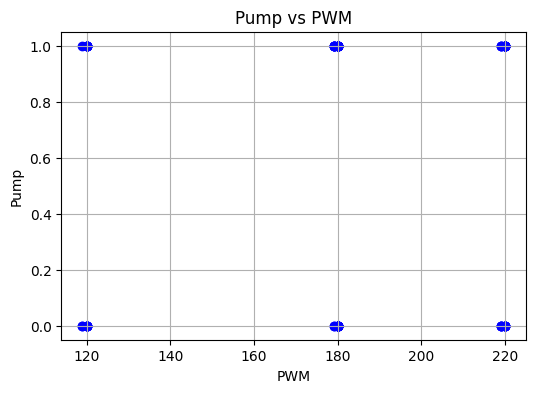

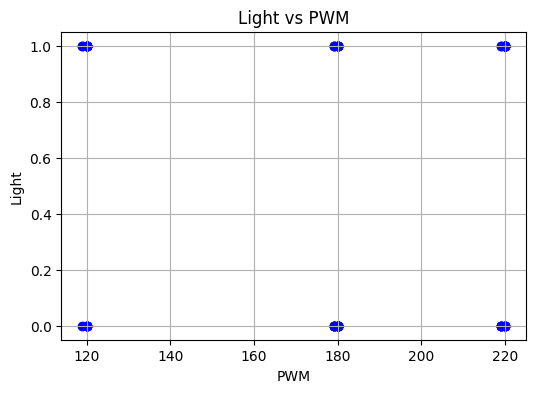

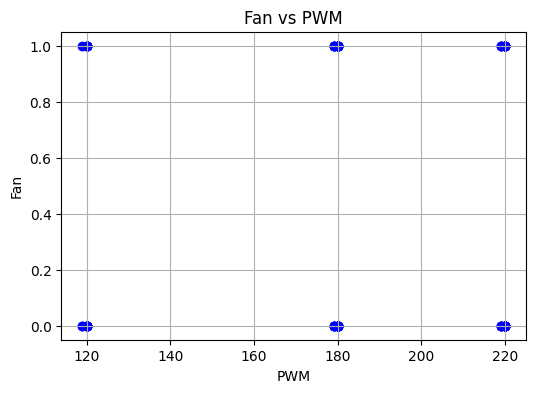

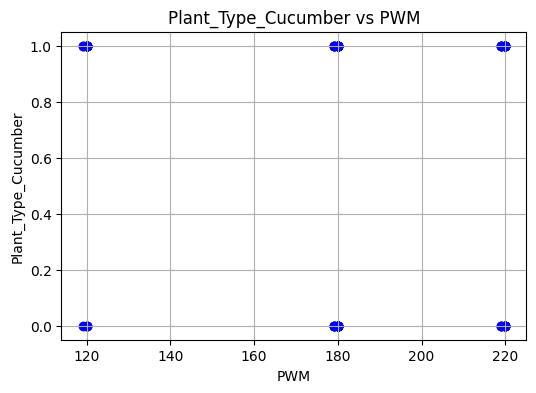

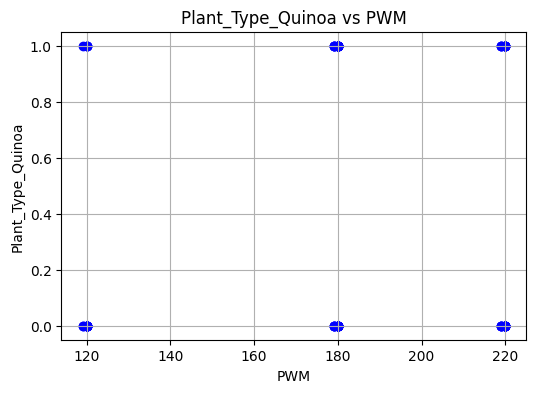

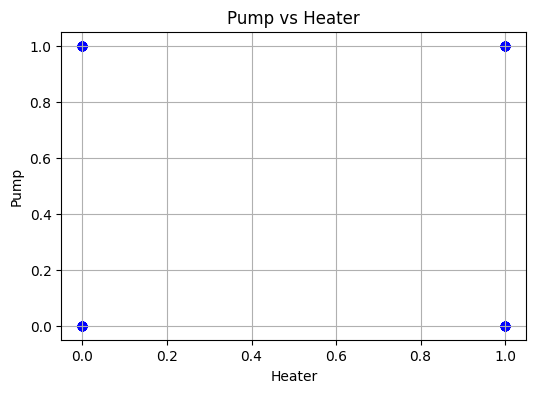

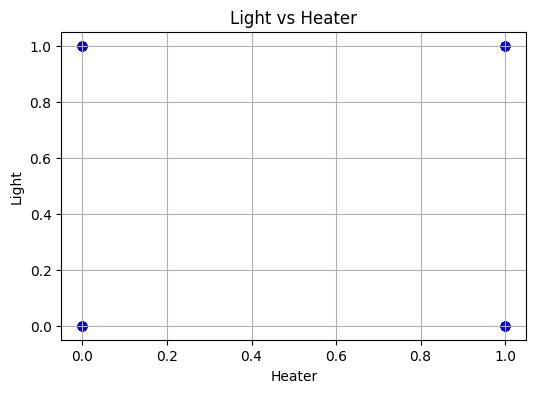

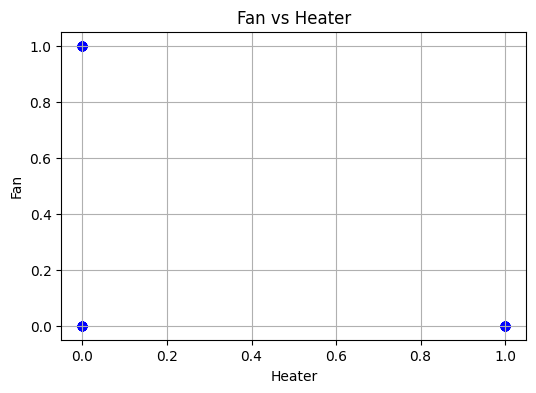

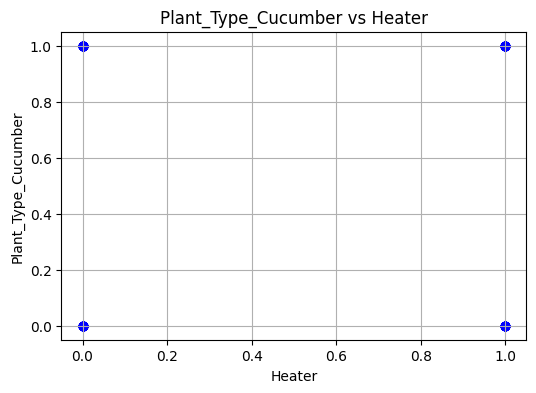

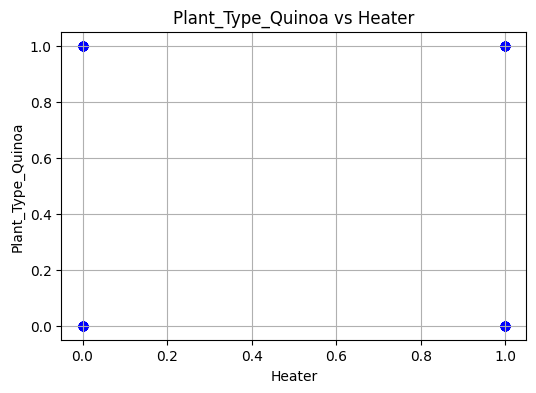

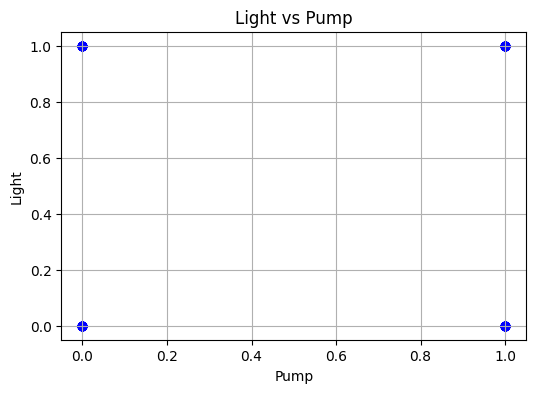

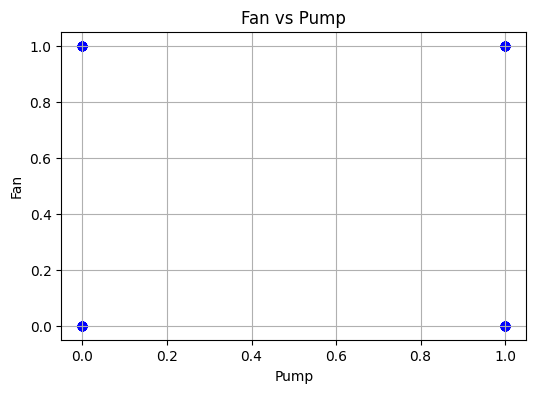

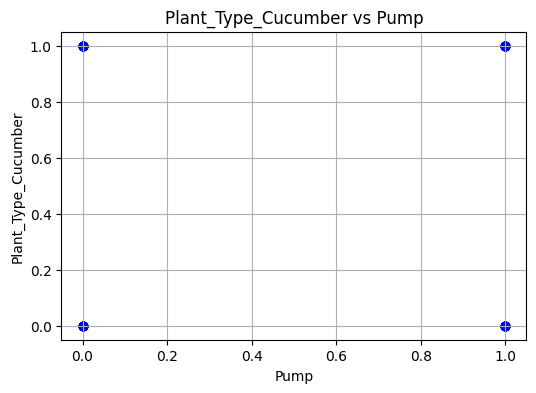

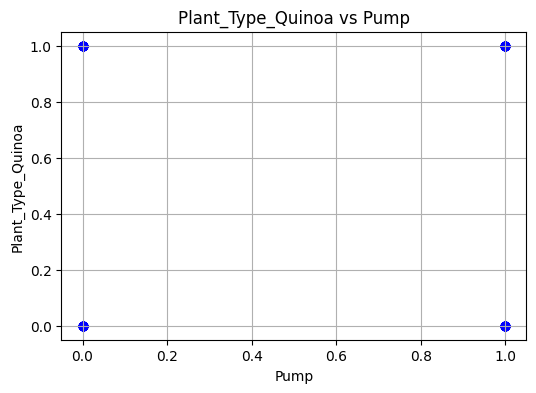

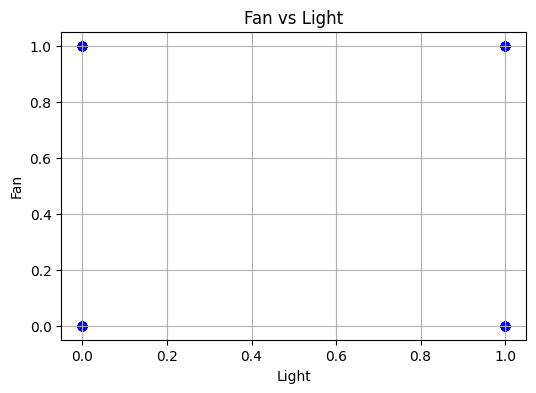

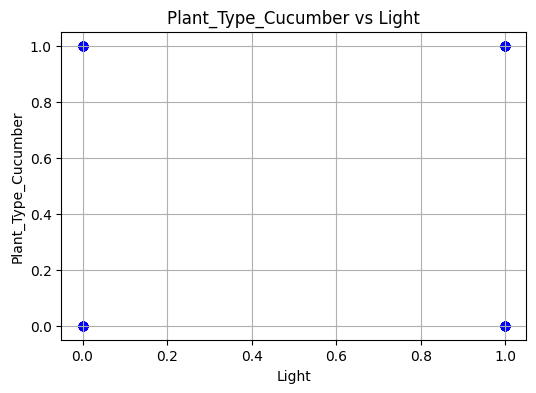

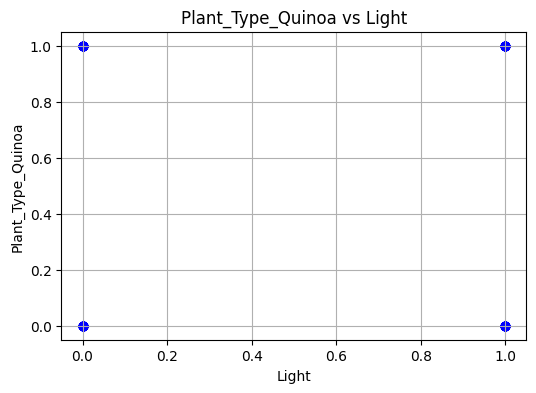

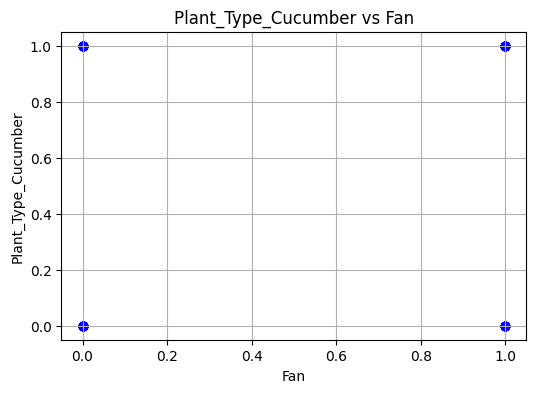

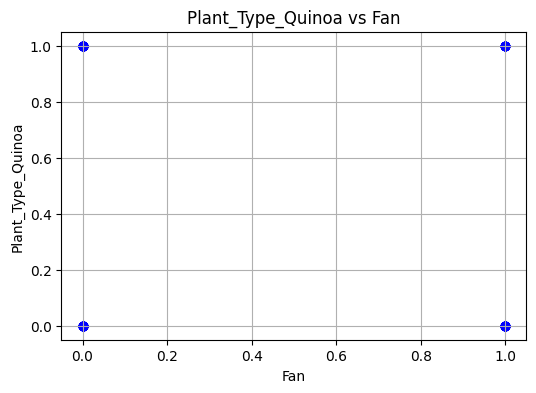

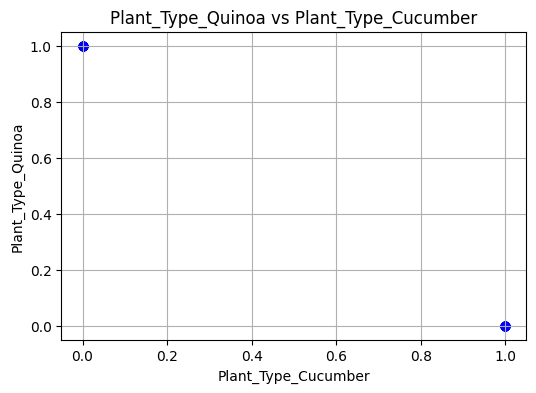

In [245]:
from itertools import combinations

cols = data.columns
pairs = list(combinations(cols, 2))
for x_col, y_col in pairs:
    plt.figure(figsize=(6,4))
    plt.scatter(data[x_col], data[y_col], color='blue')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{y_col} vs {x_col}")
    plt.grid(True)
    plt.show()

<h1 style="font-family: 'Times New Roman'; letter-spacing: 0.08em;">Spliting Data</h1>

In [246]:

X_train, X_test, Y_train, Y_test = train_test_split(X, Y ,test_size = 0.2, random_state = 42)


X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", Y_train.shape)
print("Shape of y_test:", Y_test.shape)

Shape of X_train: (64, 8)
Shape of X_test: (16, 8)
Shape of y_train: (64, 1)
Shape of y_test: (16, 1)


<h1 style="font-family: 'Times New Roman'; letter-spacing: 0.08em;">Models and Evalution </h1>

In [ ]:
models = {
"DecisionTreeClassifier":  DecisionTreeClassifier()
}

In [251]:
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, Y_train)
    preds = model.predict(X_test)
    
    acc = accuracy_score(Y_test, preds)
    report = classification_report(Y_test, preds, output_dict=True)
    cm = confusion_matrix(Y_test, preds)
    
    results[name] = {
        "Accuracy": acc,
        "Report": report,
        "Confusion Matrix": cm
    }
    
    print(f"{name} Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(Y_test, preds))


Training DecisionTreeClassifier...
DecisionTreeClassifier Accuracy: 0.8750
Classification Report:
              precision    recall  f1-score   support

    Cucumber       0.78      1.00      0.88         7
      Quinoa       1.00      0.78      0.88         9

    accuracy                           0.88        16
   macro avg       0.89      0.89      0.88        16
weighted avg       0.90      0.88      0.88        16



<h1 style="font-family: 'Times New Roman'; letter-spacing: 0.08em;">Save Model</h1>

In [256]:
import joblib

joblib.dump(model, 'model.pkl')

['model.pkl']